## 1. Setup and Imports

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.spatial.distance import cdist
import os
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Configure plotting
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("✓ All libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"OpenCV version: {cv2.__version__}")
print(f"Pillow version: {Image.__version__}")

# Create output directories
os.makedirs('../results/segmented', exist_ok=True)
os.makedirs('../results/analysis', exist_ok=True)
os.makedirs('../data', exist_ok=True)
print("\n✓ Output directories ready")

✓ All libraries imported successfully!
NumPy version: 2.3.4
OpenCV version: 4.12.0
Pillow version: 12.0.0

✓ Output directories ready


## 2. Generate or Load Sample Image

We'll create a synthetic image for demonstration, but you can also load your own images.

✓ Sample image created and saved to '../data/sample_scene.png'


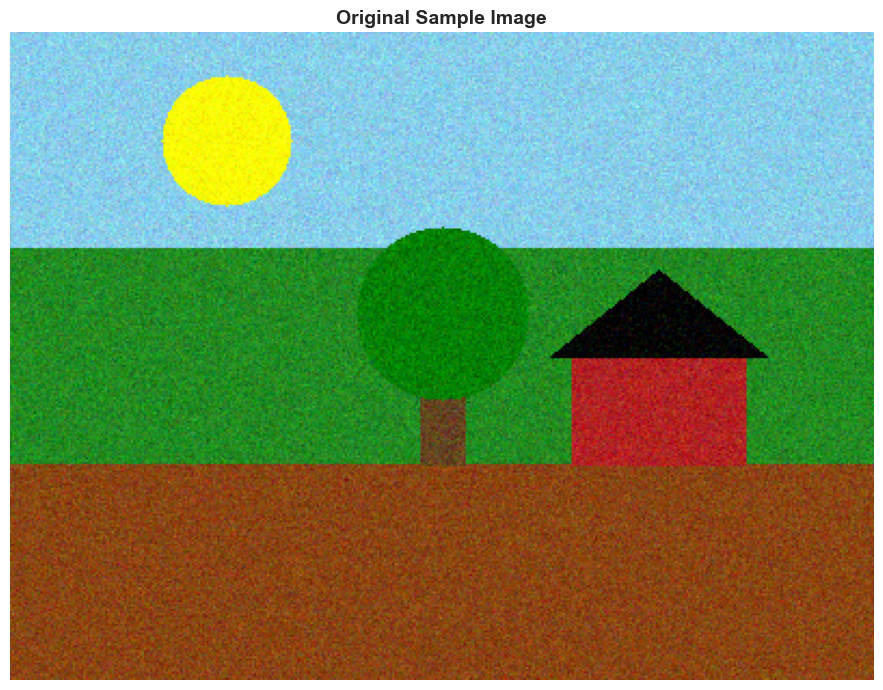


Image Details:
  Shape: (300, 400, 3)
  Size: 400 x 300 pixels
  Channels: 3
  Data type: uint8
  Value range: [0, 255]


In [2]:
def create_sample_image(width=400, height=300):
    """
    Create a sample image with distinct color regions for segmentation demo.
    """
    image = np.zeros((height, width, 3), dtype=np.uint8)
    
    # Create distinct regions with different colors
    # Sky (blue)
    image[0:height//3, :] = [135, 206, 235]  # Sky blue
    
    # Grass (green)
    image[height//3:2*height//3, :] = [34, 139, 34]  # Forest green
    
    # Ground (brown)
    image[2*height//3:, :] = [139, 69, 19]  # Saddle brown
    
    # Add some objects
    # Sun (yellow circle)
    cv2.circle(image, (width//4, height//6), 30, (255, 255, 0), -1)
    
    # Tree (green circle on brown rectangle)
    cv2.rectangle(image, (width//2-10, height//2), (width//2+10, 2*height//3), (101, 67, 33), -1)
    cv2.circle(image, (width//2, height//2-20), 40, (0, 128, 0), -1)
    
    # House (red rectangle with black roof)
    cv2.rectangle(image, (3*width//4-40, height//2), (3*width//4+40, 2*height//3), (178, 34, 34), -1)
    pts = np.array([[3*width//4-50, height//2], [3*width//4+50, height//2], 
                    [3*width//4, height//2-40]], np.int32)
    cv2.fillPoly(image, [pts], (0, 0, 0))
    
    # Add some noise for realism
    noise = np.random.normal(0, 15, image.shape).astype(np.int16)
    image = np.clip(image.astype(np.int16) + noise, 0, 255).astype(np.uint8)
    
    return image

# Create sample image
sample_image = create_sample_image()

# Save the sample image
Image.fromarray(sample_image).save('../data/sample_scene.png')
print("✓ Sample image created and saved to '../data/sample_scene.png'")

# Display the image
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(sample_image)
ax.set_title('Original Sample Image', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('../results/analysis/original_image.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nImage Details:")
print(f"  Shape: {sample_image.shape}")
print(f"  Size: {sample_image.shape[1]} x {sample_image.shape[0]} pixels")
print(f"  Channels: {sample_image.shape[2]}")
print(f"  Data type: {sample_image.dtype}")
print(f"  Value range: [{sample_image.min()}, {sample_image.max()}]")

### 2.1 Load Your Own Image (Optional)

Uncomment and run this cell to load your own image instead of using the sample.

In [ ]:
# Uncomment to load your own image
# image_path = '../data/your_image.jpg'  # Replace with your image path
# sample_image = np.array(Image.open(image_path))
# 
# # Resize if image is too large
# max_dimension = 800
# height, width = sample_image.shape[:2]
# if max(height, width) > max_dimension:
#     scale = max_dimension / max(height, width)
#     new_width = int(width * scale)
#     new_height = int(height * scale)
#     sample_image = cv2.resize(sample_image, (new_width, new_height))
#     print(f"Image resized to: {sample_image.shape}")
# 
# plt.figure(figsize=(10, 7))
# plt.imshow(sample_image)
# plt.title('Loaded Image')
# plt.axis('off')
# plt.show()

## 3. Prepare Image Data for K-Means

Convert the image into a format suitable for K-Means clustering.

Image Data Preparation:
  Original shape: (300, 400, 3)
  Pixel array shape: (120000, 3)
  Total pixels: 120,000
  Features per pixel: 3
  Color space: RGB
  Value range: [0.000, 1.000]


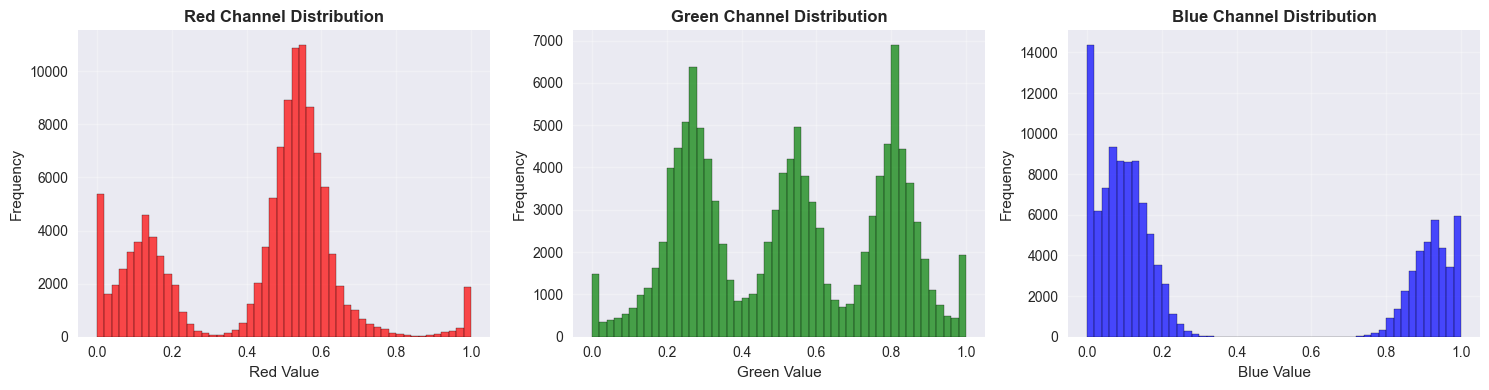

In [3]:
def prepare_image_for_clustering(image, color_space='RGB'):
    """
    Prepare image data for K-Means clustering.
    
    Parameters:
    -----------
    image : numpy.ndarray
        Input image in RGB format
    color_space : str
        Color space to use: 'RGB', 'HSV', or 'LAB'
    
    Returns:
    --------
    pixels : numpy.ndarray
        Flattened pixel array for clustering
    original_shape : tuple
        Original image shape for reconstruction
    """
    original_shape = image.shape
    
    # Convert color space if needed
    if color_space == 'HSV':
        image_converted = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    elif color_space == 'LAB':
        image_converted = cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    else:  # RGB
        image_converted = image.copy()
    
    # Reshape image to 2D array of pixels
    pixels = image_converted.reshape(-1, 3)
    
    # Normalize pixel values to [0, 1] for better clustering
    pixels = pixels.astype(np.float32) / 255.0
    
    return pixels, original_shape

# Prepare image data
color_space = 'RGB'  # Options: 'RGB', 'HSV', 'LAB'
pixel_data, original_shape = prepare_image_for_clustering(sample_image, color_space)

print("Image Data Preparation:")
print("="*50)
print(f"  Original shape: {original_shape}")
print(f"  Pixel array shape: {pixel_data.shape}")
print(f"  Total pixels: {pixel_data.shape[0]:,}")
print(f"  Features per pixel: {pixel_data.shape[1]}")
print(f"  Color space: {color_space}")
print(f"  Value range: [{pixel_data.min():.3f}, {pixel_data.max():.3f}]")

# Display color distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
color_names = ['Red', 'Green', 'Blue'] if color_space == 'RGB' else \
              ['Hue', 'Saturation', 'Value'] if color_space == 'HSV' else \
              ['L', 'A', 'B']

for i, (ax, name) in enumerate(zip(axes, color_names)):
    ax.hist(pixel_data[:, i], bins=50, color=['red', 'green', 'blue'][i], alpha=0.7, edgecolor='black')
    ax.set_xlabel(f'{name} Value', fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{name} Channel Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/analysis/color_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Determine Optimal Number of Clusters (Elbow Method)

Use the elbow method to find the optimal K value.

Finding optimal K...
--------------------------------------------------
  K=2: Inertia=381.7494, Silhouette=0.6909
  K=3: Inertia=154.1884, Silhouette=0.7130
  K=2: Inertia=381.7494, Silhouette=0.6909
  K=3: Inertia=154.1884, Silhouette=0.7130
  K=4: Inertia=82.3819, Silhouette=0.7504
  K=5: Inertia=57.8561, Silhouette=0.7683
  K=4: Inertia=82.3819, Silhouette=0.7504
  K=5: Inertia=57.8561, Silhouette=0.7683
  K=6: Inertia=49.5980, Silhouette=0.6376
  K=7: Inertia=43.9195, Silhouette=0.5350
  K=6: Inertia=49.5980, Silhouette=0.6376
  K=7: Inertia=43.9195, Silhouette=0.5350
  K=8: Inertia=40.2555, Silhouette=0.4743
  K=9: Inertia=37.0250, Silhouette=0.2804
  K=8: Inertia=40.2555, Silhouette=0.4743
  K=9: Inertia=37.0250, Silhouette=0.2804
  K=10: Inertia=34.8119, Silhouette=0.2621
  K=10: Inertia=34.8119, Silhouette=0.2621


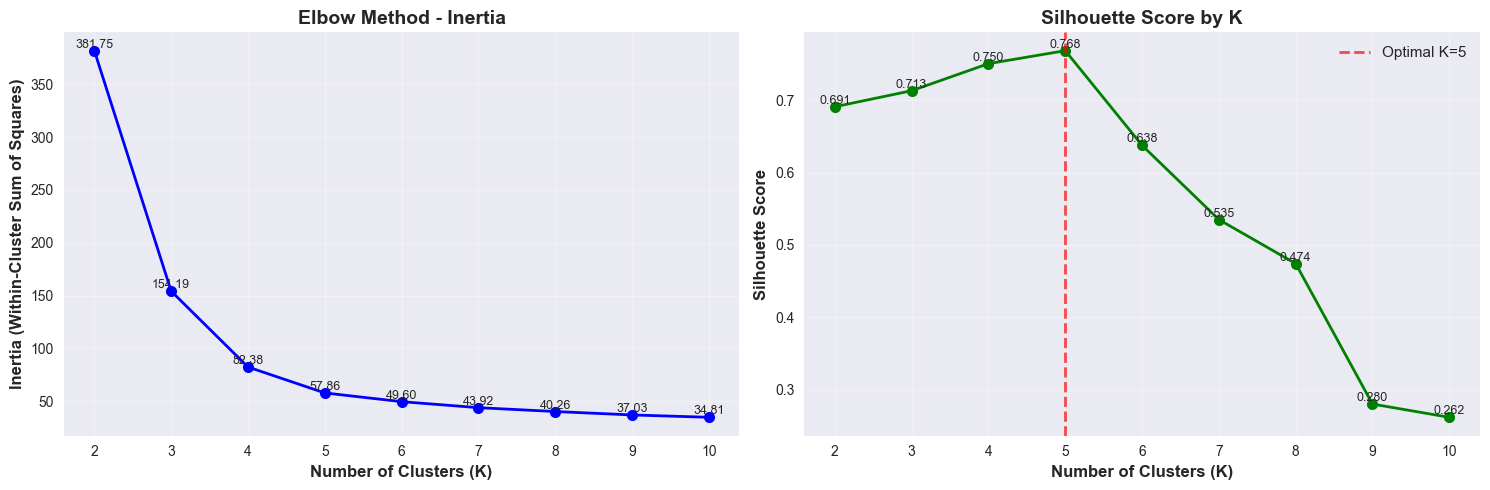


📊 Suggested optimal K: 5


In [4]:
def find_optimal_k(pixels, k_range=range(2, 11), sample_size=5000):
    """
    Find optimal number of clusters using elbow method.
    
    Parameters:
    -----------
    pixels : numpy.ndarray
        Pixel data for clustering
    k_range : range
        Range of K values to test
    sample_size : int
        Number of pixels to sample for faster computation
    
    Returns:
    --------
    inertias : list
        List of inertia values for each K
    silhouette_scores : list
        List of silhouette scores for each K
    """
    # Sample pixels for faster computation
    if len(pixels) > sample_size:
        indices = np.random.choice(len(pixels), sample_size, replace=False)
        pixels_sample = pixels[indices]
    else:
        pixels_sample = pixels
    
    inertias = []
    silhouette_scores = []
    
    print("Finding optimal K...")
    print("-" * 50)
    
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        kmeans.fit(pixels_sample)
        
        inertias.append(kmeans.inertia_)
        
        # Calculate silhouette score (skip if too many samples)
        if len(pixels_sample) <= 10000:
            sil_score = silhouette_score(pixels_sample, kmeans.labels_, sample_size=min(5000, len(pixels_sample)))
            silhouette_scores.append(sil_score)
        
        print(f"  K={k}: Inertia={kmeans.inertia_:.4f}" + 
              (f", Silhouette={silhouette_scores[-1]:.4f}" if silhouette_scores else ""))
    
    return inertias, silhouette_scores

# Find optimal K
k_range = range(2, 11)
inertias, silhouette_scores = find_optimal_k(pixel_data, k_range)

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Inertia plot
axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
axes[0].set_title('Elbow Method - Inertia', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(k_range)

# Add value labels
for k, inertia in zip(k_range, inertias):
    axes[0].text(k, inertia, f'{inertia:.2f}', ha='center', va='bottom', fontsize=9)

# Silhouette score plot
if silhouette_scores:
    axes[1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
    axes[1].set_title('Silhouette Score by K', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(k_range)
    
    # Add value labels
    for k, score in zip(k_range, silhouette_scores):
        axes[1].text(k, score, f'{score:.3f}', ha='center', va='bottom', fontsize=9)
    
    # Find optimal K (highest silhouette score)
    optimal_k = list(k_range)[np.argmax(silhouette_scores)]
    axes[1].axvline(x=optimal_k, color='red', linestyle='--', linewidth=2, alpha=0.7, 
                    label=f'Optimal K={optimal_k}')
    axes[1].legend(fontsize=11)
else:
    axes[1].text(0.5, 0.5, 'Silhouette scores\nnot computed\n(too many samples)', 
                ha='center', va='center', transform=axes[1].transAxes, fontsize=12)
    axes[1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
    optimal_k = 5  # Default value

plt.tight_layout()
plt.savefig('../results/analysis/elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📊 Suggested optimal K: {optimal_k}")

## 5. Apply K-Means Clustering

Perform image segmentation using K-Means with the selected number of clusters.

In [5]:
def segment_image_kmeans(pixels, original_shape, n_clusters=5, color_space='RGB'):
    """
    Segment image using K-Means clustering.
    
    Parameters:
    -----------
    pixels : numpy.ndarray
        Flattened pixel array
    original_shape : tuple
        Original image shape
    n_clusters : int
        Number of clusters (K)
    color_space : str
        Color space used: 'RGB', 'HSV', or 'LAB'
    
    Returns:
    --------
    segmented_image : numpy.ndarray
        Segmented image in RGB format
    labels : numpy.ndarray
        Cluster labels for each pixel
    cluster_centers : numpy.ndarray
        Cluster center colors
    kmeans : KMeans
        Fitted KMeans model
    """
    print(f"\nPerforming K-Means clustering with K={n_clusters}...")
    print("-" * 50)
    
    # Apply K-Means
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10, max_iter=300, verbose=0)
    labels = kmeans.fit_predict(pixels)
    cluster_centers = kmeans.cluster_centers_
    
    print(f"✓ Clustering complete!")
    print(f"  Iterations: {kmeans.n_iter_}")
    print(f"  Inertia: {kmeans.inertia_:.4f}")
    
    # Create segmented image using cluster centers
    segmented_pixels = cluster_centers[labels]
    
    # Convert back to uint8 [0, 255]
    segmented_pixels = (segmented_pixels * 255).astype(np.uint8)
    
    # Reshape to original image shape
    segmented_image = segmented_pixels.reshape(original_shape)
    
    # Convert back to RGB if different color space was used
    if color_space == 'HSV':
        segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_HSV2RGB)
    elif color_space == 'LAB':
        segmented_image = cv2.cvtColor(segmented_image, cv2.COLOR_LAB2RGB)
    
    # Calculate cluster statistics
    unique, counts = np.unique(labels, return_counts=True)
    print(f"\n📊 Cluster Statistics:")
    for cluster_id, count in zip(unique, counts):
        percentage = (count / len(labels)) * 100
        print(f"  Cluster {cluster_id}: {count:,} pixels ({percentage:.2f}%)")
    
    return segmented_image, labels.reshape(original_shape[:2]), cluster_centers, kmeans

# Set number of clusters
n_clusters = 6  # You can adjust this based on the elbow method results

# Perform segmentation
segmented_image, label_map, cluster_centers, kmeans_model = segment_image_kmeans(
    pixel_data, original_shape, n_clusters, color_space
)


Performing K-Means clustering with K=6...
--------------------------------------------------
✓ Clustering complete!
  Iterations: 9
  Inertia: 1191.9862

📊 Cluster Statistics:
  Cluster 0: 36,843 pixels (30.70%)
  Cluster 1: 33,637 pixels (28.03%)
  Cluster 2: 9,446 pixels (7.87%)
  Cluster 3: 2,821 pixels (2.35%)
  Cluster 4: 35,151 pixels (29.29%)
  Cluster 5: 2,102 pixels (1.75%)
✓ Clustering complete!
  Iterations: 9
  Inertia: 1191.9862

📊 Cluster Statistics:
  Cluster 0: 36,843 pixels (30.70%)
  Cluster 1: 33,637 pixels (28.03%)
  Cluster 2: 9,446 pixels (7.87%)
  Cluster 3: 2,821 pixels (2.35%)
  Cluster 4: 35,151 pixels (29.29%)
  Cluster 5: 2,102 pixels (1.75%)


## 6. Visualize Segmentation Results

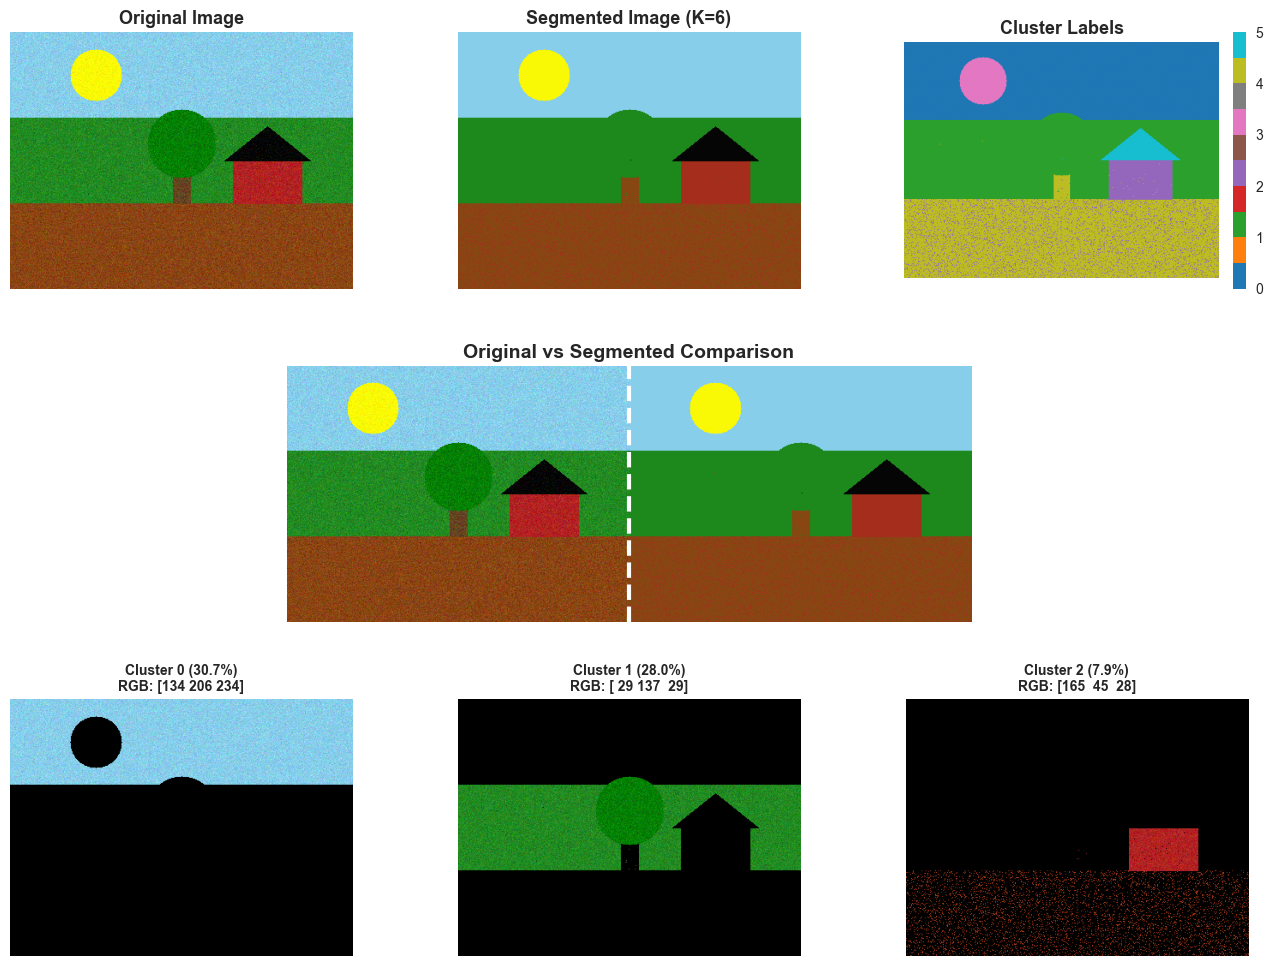

✓ Segmentation visualization saved


In [6]:
# Create comprehensive visualization
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Original image
ax1 = fig.add_subplot(gs[0, 0])
ax1.imshow(sample_image)
ax1.set_title('Original Image', fontsize=13, fontweight='bold')
ax1.axis('off')

# Segmented image
ax2 = fig.add_subplot(gs[0, 1])
ax2.imshow(segmented_image)
ax2.set_title(f'Segmented Image (K={n_clusters})', fontsize=13, fontweight='bold')
ax2.axis('off')

# Cluster labels
ax3 = fig.add_subplot(gs[0, 2])
im = ax3.imshow(label_map, cmap='tab10')
ax3.set_title('Cluster Labels', fontsize=13, fontweight='bold')
ax3.axis('off')
plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

# Side-by-side comparison
ax4 = fig.add_subplot(gs[1, :])
comparison = np.hstack([sample_image, segmented_image])
ax4.imshow(comparison)
ax4.set_title('Original vs Segmented Comparison', fontsize=14, fontweight='bold')
ax4.axis('off')
# Add dividing line
ax4.axvline(x=sample_image.shape[1], color='white', linewidth=3, linestyle='--')

# Individual cluster visualizations
for i in range(min(n_clusters, 6)):
    row = 2 + i // 3
    col = i % 3
    if row < 3:  # Only show first 3 clusters in the available space
        ax = fig.add_subplot(gs[2, col])
        
        # Create mask for this cluster
        cluster_mask = (label_map == i).astype(np.uint8) * 255
        
        # Apply mask to original image
        masked_image = sample_image.copy()
        for c in range(3):
            masked_image[:, :, c] = (masked_image[:, :, c] * (cluster_mask / 255)).astype(np.uint8)
        
        ax.imshow(masked_image)
        
        # Count pixels in this cluster
        pixel_count = np.sum(label_map == i)
        percentage = (pixel_count / label_map.size) * 100
        
        # Get cluster center color
        center_color = (cluster_centers[i] * 255).astype(np.uint8)
        
        ax.set_title(f'Cluster {i} ({percentage:.1f}%)\nRGB: {center_color}', 
                    fontsize=10, fontweight='bold')
        ax.axis('off')

plt.savefig('../results/segmented/segmentation_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Segmentation visualization saved")

## 7. Visualize Cluster Centers in Color Space

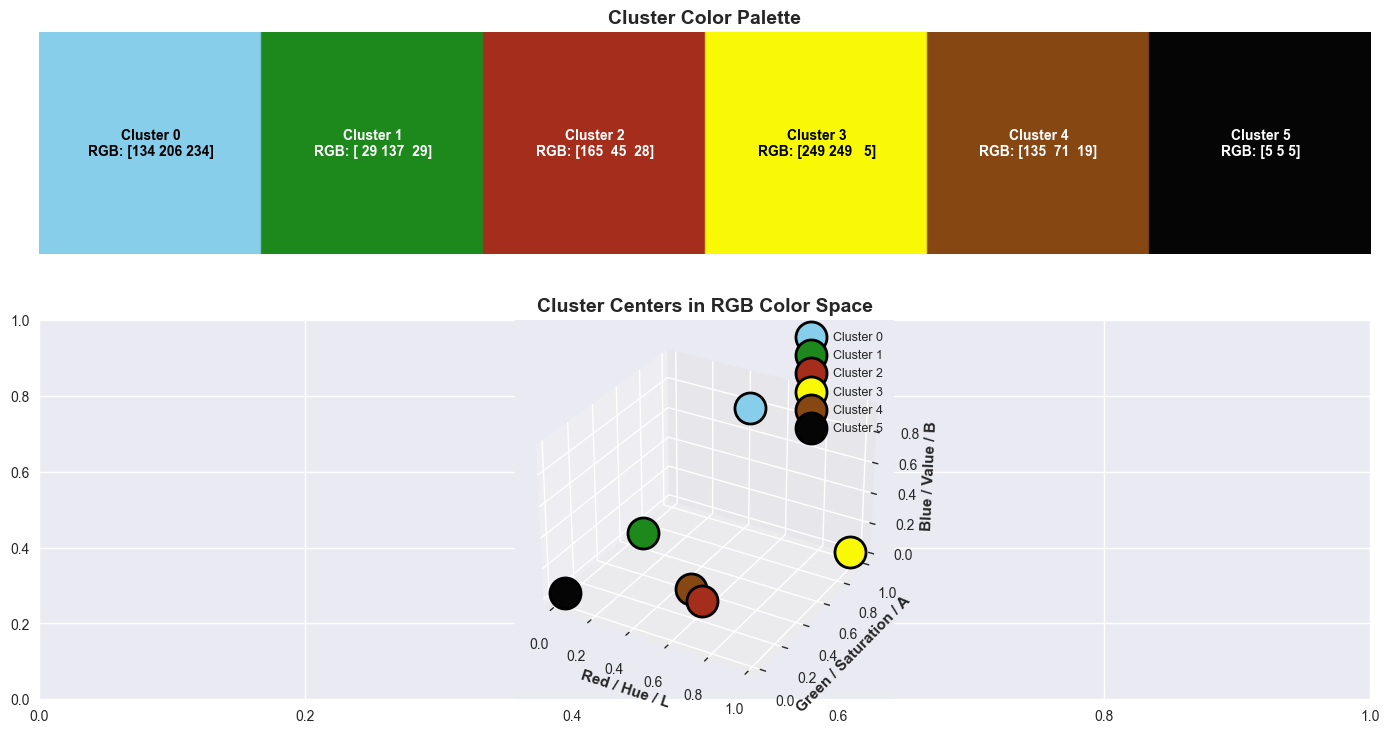

In [7]:
# Display cluster centers as color palette
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Create color palette
ax1 = axes[0]
palette = np.zeros((100, n_clusters * 100, 3), dtype=np.uint8)
for i in range(n_clusters):
    color = (cluster_centers[i] * 255).astype(np.uint8)
    palette[:, i*100:(i+1)*100] = color

ax1.imshow(palette)
ax1.set_title('Cluster Color Palette', fontsize=14, fontweight='bold')
ax1.axis('off')

# Add labels
for i in range(n_clusters):
    color = (cluster_centers[i] * 255).astype(np.uint8)
    ax1.text(i*100 + 50, 50, f'Cluster {i}\nRGB: {color}', 
            ha='center', va='center', fontsize=10, fontweight='bold',
            color='white' if np.mean(color) < 128 else 'black')

# 3D scatter plot of cluster centers
ax2 = fig.add_subplot(2, 1, 2, projection='3d')

# Convert cluster centers back to [0, 255] for display
centers_rgb = (cluster_centers * 255).astype(np.uint8) / 255.0

for i in range(n_clusters):
    ax2.scatter(cluster_centers[i, 0], cluster_centers[i, 1], cluster_centers[i, 2],
               c=[centers_rgb[i]], s=500, marker='o', edgecolors='black', linewidth=2,
               label=f'Cluster {i}')

ax2.set_xlabel('Red / Hue / L', fontsize=11, fontweight='bold')
ax2.set_ylabel('Green / Saturation / A', fontsize=11, fontweight='bold')
ax2.set_zlabel('Blue / Value / B', fontsize=11, fontweight='bold')
ax2.set_title(f'Cluster Centers in {color_space} Color Space', fontsize=14, fontweight='bold')
ax2.legend(fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/analysis/cluster_centers.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Segmentation Quality Metrics

In [8]:
print("="*70)
print("SEGMENTATION QUALITY METRICS")
print("="*70)

# Sample pixels for metric calculation if too many
sample_size = min(10000, len(pixel_data))
if len(pixel_data) > sample_size:
    indices = np.random.choice(len(pixel_data), sample_size, replace=False)
    pixels_sample = pixel_data[indices]
    labels_sample = kmeans_model.predict(pixels_sample)
else:
    pixels_sample = pixel_data
    labels_sample = kmeans_model.labels_

# 1. Inertia (Within-Cluster Sum of Squares)
inertia = kmeans_model.inertia_
print(f"\n1. Inertia (WCSS): {inertia:.4f}")
print("   Lower is better - measures compactness of clusters")

# 2. Silhouette Score
if len(pixels_sample) <= 10000:
    silhouette = silhouette_score(pixels_sample, labels_sample, sample_size=min(5000, len(pixels_sample)))
    print(f"\n2. Silhouette Score: {silhouette:.4f}")
    print("   Range: [-1, 1], Higher is better")
    print("   Measures how well-separated the clusters are")
    if silhouette > 0.5:
        print("   ✓ Good clustering structure")
    elif silhouette > 0.25:
        print("   ⚠ Moderate clustering structure")
    else:
        print("   ✗ Poor clustering structure")
else:
    print(f"\n2. Silhouette Score: Not computed (too many samples)")

# 3. Davies-Bouldin Index
if len(pixels_sample) <= 10000:
    db_index = davies_bouldin_score(pixels_sample, labels_sample)
    print(f"\n3. Davies-Bouldin Index: {db_index:.4f}")
    print("   Lower is better - measures cluster separation")
    if db_index < 1.0:
        print("   ✓ Good cluster separation")
    elif db_index < 2.0:
        print("   ⚠ Moderate cluster separation")
    else:
        print("   ✗ Poor cluster separation")
else:
    print(f"\n3. Davies-Bouldin Index: Not computed (too many samples)")

# 4. Cluster size distribution
unique, counts = np.unique(label_map, return_counts=True)
print(f"\n4. Cluster Size Distribution:")
for cluster_id, count in zip(unique, counts):
    percentage = (count / label_map.size) * 100
    bar = '█' * int(percentage / 2)
    print(f"   Cluster {cluster_id}: {bar} {percentage:5.2f}% ({count:,} pixels)")

# 5. Color variance within clusters
print(f"\n5. Within-Cluster Color Variance:")
for i in range(n_clusters):
    cluster_pixels = pixel_data[kmeans_model.labels_ == i]
    variance = np.var(cluster_pixels, axis=0).mean()
    print(f"   Cluster {i}: {variance:.6f}")

# Calculate compression ratio
original_size = original_shape[0] * original_shape[1] * 3 * 8  # bits
compressed_size = (n_clusters * 3 * 8) + (original_shape[0] * original_shape[1] * np.ceil(np.log2(n_clusters)))  # bits
compression_ratio = original_size / compressed_size

print(f"\n6. Compression Information:")
print(f"   Original size: {original_size:,} bits ({original_size/8:,.0f} bytes)")
print(f"   Compressed size: {compressed_size:,.0f} bits ({compressed_size/8:,.0f} bytes)")
print(f"   Compression ratio: {compression_ratio:.2f}:1")
print(f"   Space saved: {(1 - compressed_size/original_size)*100:.2f}%")

print("\n" + "="*70)

SEGMENTATION QUALITY METRICS

1. Inertia (WCSS): 1191.9862
   Lower is better - measures compactness of clusters

2. Silhouette Score: 0.6285
   Range: [-1, 1], Higher is better
   Measures how well-separated the clusters are
   ✓ Good clustering structure

3. Davies-Bouldin Index: 0.5702
   Lower is better - measures cluster separation
   ✓ Good cluster separation

4. Cluster Size Distribution:
   Cluster 0: ███████████████ 30.70% (36,843 pixels)
   Cluster 1: ██████████████ 28.03% (33,637 pixels)
   Cluster 2: ███  7.87% (9,446 pixels)
   Cluster 3: █  2.35% (2,821 pixels)
   Cluster 4: ██████████████ 29.29% (35,151 pixels)
   Cluster 5:   1.75% (2,102 pixels)

5. Within-Cluster Color Variance:
   Cluster 0: 0.003128
   Cluster 1: 0.004121
   Cluster 2: 0.003964
   Cluster 3: 0.001088
   Cluster 4: 0.002858
   Cluster 5: 0.001185

6. Compression Information:
   Original size: 2,880,000 bits (360,000 bytes)
   Compressed size: 360,144 bits (45,018 bytes)
   Compression ratio: 8.00:1
 

## 9. Compare Different K Values

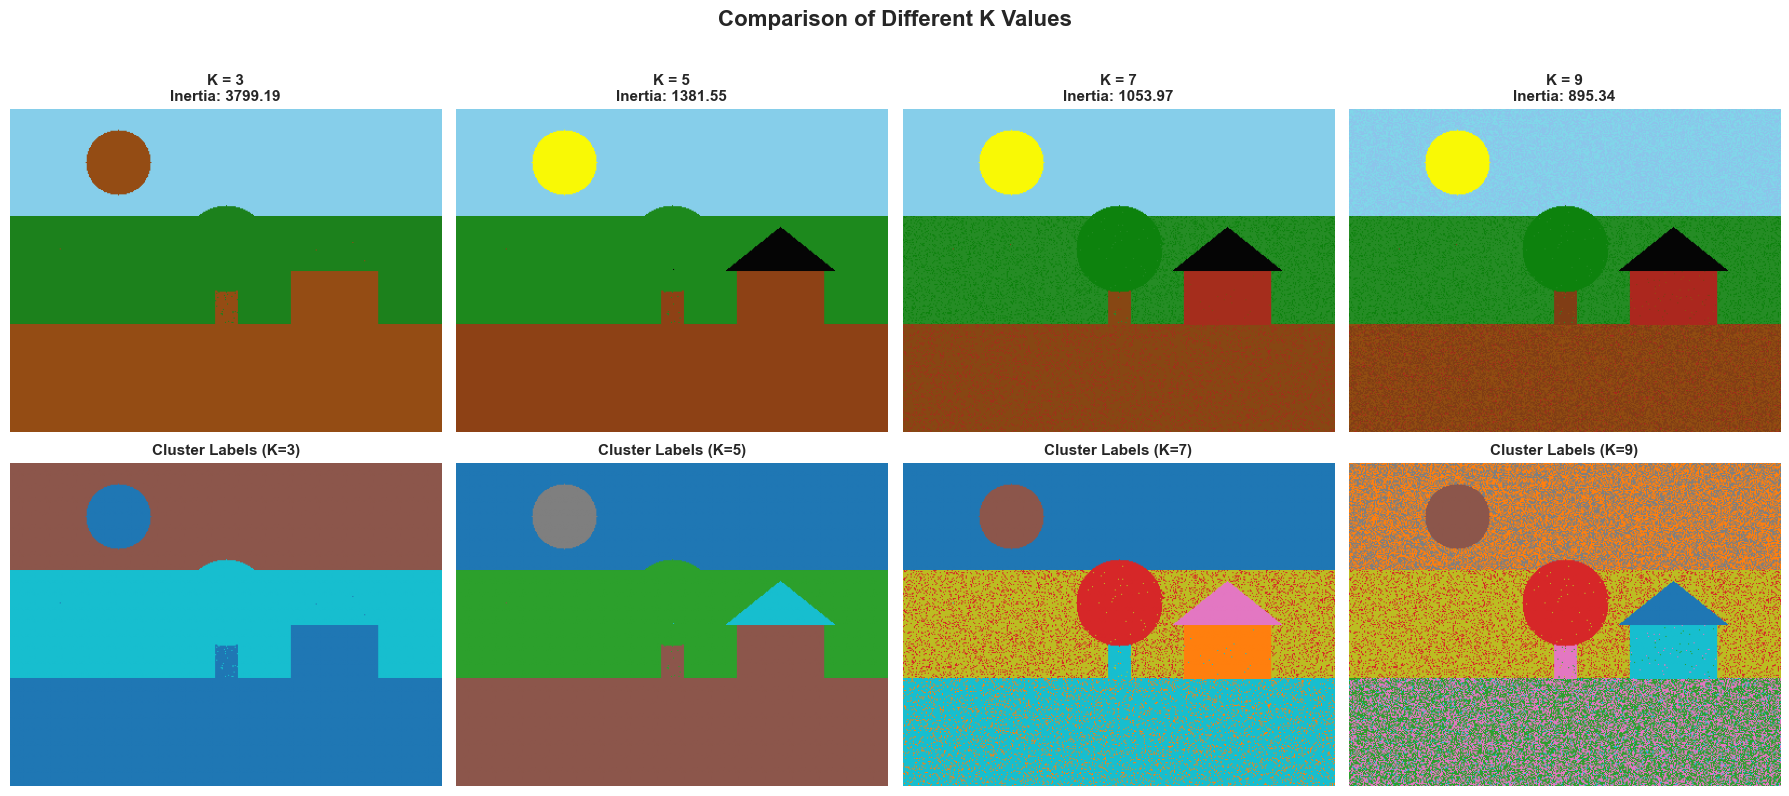

✓ K-value comparison saved


In [9]:
# Compare segmentation with different K values
k_values = [3, 5, 7, 9]

fig, axes = plt.subplots(2, len(k_values), figsize=(18, 8))

for idx, k in enumerate(k_values):
    # Perform segmentation
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
    labels_temp = kmeans_temp.fit_predict(pixel_data)
    centers_temp = kmeans_temp.cluster_centers_
    
    # Create segmented image
    segmented_temp = (centers_temp[labels_temp] * 255).astype(np.uint8).reshape(original_shape)
    
    # Convert back to RGB if needed
    if color_space == 'HSV':
        segmented_temp = cv2.cvtColor(segmented_temp, cv2.COLOR_HSV2RGB)
    elif color_space == 'LAB':
        segmented_temp = cv2.cvtColor(segmented_temp, cv2.COLOR_LAB2RGB)
    
    # Plot segmented image
    axes[0, idx].imshow(segmented_temp)
    axes[0, idx].set_title(f'K = {k}\nInertia: {kmeans_temp.inertia_:.2f}', 
                          fontsize=11, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Plot cluster labels
    label_map_temp = labels_temp.reshape(original_shape[:2])
    im = axes[1, idx].imshow(label_map_temp, cmap='tab10')
    axes[1, idx].set_title(f'Cluster Labels (K={k})', fontsize=11, fontweight='bold')
    axes[1, idx].axis('off')

plt.suptitle('Comparison of Different K Values', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/analysis/k_value_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ K-value comparison saved")

## 10. Save Results

In [10]:
# Save segmented image
segmented_pil = Image.fromarray(segmented_image)
segmented_pil.save(f'../results/segmented/segmented_k{n_clusters}.png')
print(f"✓ Segmented image saved: ../results/segmented/segmented_k{n_clusters}.png")

# Save label map
label_map_colored = (label_map * (255 // n_clusters)).astype(np.uint8)
Image.fromarray(label_map_colored).save(f'../results/segmented/labels_k{n_clusters}.png')
print(f"✓ Label map saved: ../results/segmented/labels_k{n_clusters}.png")

# Save cluster information
cluster_info = []
for i in range(n_clusters):
    color = (cluster_centers[i] * 255).astype(np.uint8)
    pixel_count = np.sum(label_map == i)
    percentage = (pixel_count / label_map.size) * 100
    
    cluster_info.append({
        'Cluster': i,
        'R': color[0],
        'G': color[1],
        'B': color[2],
        'Pixel Count': pixel_count,
        'Percentage': f'{percentage:.2f}%'
    })

cluster_df = pd.DataFrame(cluster_info)
cluster_df.to_csv(f'../results/segmented/cluster_info_k{n_clusters}.csv', index=False)
print(f"✓ Cluster information saved: ../results/segmented/cluster_info_k{n_clusters}.csv")

# Save summary report
report_filename = f'../results/segmented/segmentation_report_k{n_clusters}.txt'
with open(report_filename, 'w') as f:
    f.write("IMAGE SEGMENTATION REPORT - K-MEANS CLUSTERING\n")
    f.write("=" * 70 + "\n\n")
    
    f.write("PARAMETERS:\n")
    f.write(f"  Number of clusters (K): {n_clusters}\n")
    f.write(f"  Color space: {color_space}\n")
    f.write(f"  Image shape: {original_shape}\n")
    f.write(f"  Total pixels: {original_shape[0] * original_shape[1]:,}\n\n")
    
    f.write("CLUSTERING RESULTS:\n")
    f.write(f"  Iterations: {kmeans_model.n_iter_}\n")
    f.write(f"  Inertia: {kmeans_model.inertia_:.4f}\n\n")
    
    f.write("CLUSTER INFORMATION:\n")
    for i in range(n_clusters):
        color = (cluster_centers[i] * 255).astype(np.uint8)
        pixel_count = np.sum(label_map == i)
        percentage = (pixel_count / label_map.size) * 100
        f.write(f"\n  Cluster {i}:\n")
        f.write(f"    RGB Color: ({color[0]}, {color[1]}, {color[2]})\n")
        f.write(f"    Pixel Count: {pixel_count:,}\n")
        f.write(f"    Percentage: {percentage:.2f}%\n")
    
    f.write("\n" + "=" * 70 + "\n")

print(f"✓ Segmentation report saved: {report_filename}")

print("\n" + "="*70)
print("✅ ALL RESULTS SAVED SUCCESSFULLY!")
print("="*70)
print("\nOutput files:")
print(f"  • Segmented image: ../results/segmented/segmented_k{n_clusters}.png")
print(f"  • Label map: ../results/segmented/labels_k{n_clusters}.png")
print(f"  • Cluster info: ../results/segmented/cluster_info_k{n_clusters}.csv")
print(f"  • Report: ../results/segmented/segmentation_report_k{n_clusters}.txt")
print(f"  • Analysis plots: ../results/analysis/")

✓ Segmented image saved: ../results/segmented/segmented_k6.png
✓ Label map saved: ../results/segmented/labels_k6.png
✓ Cluster information saved: ../results/segmented/cluster_info_k6.csv
✓ Segmentation report saved: ../results/segmented/segmentation_report_k6.txt

✅ ALL RESULTS SAVED SUCCESSFULLY!

Output files:
  • Segmented image: ../results/segmented/segmented_k6.png
  • Label map: ../results/segmented/labels_k6.png
  • Cluster info: ../results/segmented/cluster_info_k6.csv
  • Report: ../results/segmented/segmentation_report_k6.txt
  • Analysis plots: ../results/analysis/


## 11. Summary and Conclusions

In [11]:
print("="*70)
print("K-MEANS IMAGE SEGMENTATION SUMMARY")
print("="*70)

print("\n🖼️ IMAGE INFORMATION:")
print("-" * 50)
print(f"  Dimensions: {original_shape[1]} x {original_shape[0]} pixels")
print(f"  Total pixels: {original_shape[0] * original_shape[1]:,}")
print(f"  Color channels: {original_shape[2]}")
print(f"  Color space used: {color_space}")

print("\n🎨 SEGMENTATION PARAMETERS:")
print("-" * 50)
print(f"  Number of clusters (K): {n_clusters}")
print(f"  Algorithm: K-Means")
print(f"  Initialization: k-means++")
print(f"  Random state: 42")
print(f"  Convergence iterations: {kmeans_model.n_iter_}")

print("\n📊 SEGMENTATION QUALITY:")
print("-" * 50)
print(f"  Inertia (WCSS): {kmeans_model.inertia_:.4f}")
print(f"  Compression ratio: {compression_ratio:.2f}:1")
print(f"  Space saved: {(1 - compressed_size/original_size)*100:.2f}%")

print("\n🎯 CLUSTER DISTRIBUTION:")
print("-" * 50)
unique, counts = np.unique(label_map, return_counts=True)
for cluster_id, count in sorted(zip(unique, counts), key=lambda x: x[1], reverse=True):
    percentage = (count / label_map.size) * 100
    color = (cluster_centers[cluster_id] * 255).astype(np.uint8)
    print(f"  Cluster {cluster_id}: {percentage:5.2f}% - RGB{tuple(color)}")

print("\n💡 KEY INSIGHTS:")
print("-" * 50)
print(f"  • Image successfully segmented into {n_clusters} distinct regions")
print(f"  • Clustering converged in {kmeans_model.n_iter_} iterations")
print(f"  • {compression_ratio:.1f}x compression achieved through color quantization")
print(f"  • Most dominant cluster covers {max(counts)/label_map.size*100:.1f}% of image")

print("\n🔧 POSSIBLE IMPROVEMENTS:")
print("-" * 50)
print("  • Try different color spaces (RGB, HSV, LAB) for better results")
print("  • Experiment with different K values using elbow method")
print("  • Apply preprocessing (smoothing, denoising) before segmentation")
print("  • Use spatial features along with color for more accurate segments")
print("  • Try alternative algorithms (Mean Shift, DBSCAN, Watershed)")

print("\n📁 OUTPUT FILES:")
print("-" * 50)
print("  • Original image plot")
print("  • Color distribution analysis")
print("  • Elbow method visualization")
print("  • Segmented images with different K values")
print("  • Cluster visualization and analysis")
print("  • Detailed segmentation report")

print("\n" + "="*70)
print("✅ K-MEANS IMAGE SEGMENTATION COMPLETE!")
print("="*70)

K-MEANS IMAGE SEGMENTATION SUMMARY

🖼️ IMAGE INFORMATION:
--------------------------------------------------
  Dimensions: 400 x 300 pixels
  Total pixels: 120,000
  Color channels: 3
  Color space used: RGB

🎨 SEGMENTATION PARAMETERS:
--------------------------------------------------
  Number of clusters (K): 6
  Algorithm: K-Means
  Initialization: k-means++
  Random state: 42
  Convergence iterations: 9

📊 SEGMENTATION QUALITY:
--------------------------------------------------
  Inertia (WCSS): 1191.9862
  Compression ratio: 8.00:1
  Space saved: 87.50%

🎯 CLUSTER DISTRIBUTION:
--------------------------------------------------
  Cluster 0: 30.70% - RGB(np.uint8(134), np.uint8(206), np.uint8(234))
  Cluster 4: 29.29% - RGB(np.uint8(135), np.uint8(71), np.uint8(19))
  Cluster 1: 28.03% - RGB(np.uint8(29), np.uint8(137), np.uint8(29))
  Cluster 2:  7.87% - RGB(np.uint8(165), np.uint8(45), np.uint8(28))
  Cluster 3:  2.35% - RGB(np.uint8(249), np.uint8(249), np.uint8(5))
  Cluster 5: